# 2D Ising Model Simulation with Monte Carlo

## Exercise 1: Implementation of the Metropolis Algorithm

## Task 1: Measurement of Physical Observables


Running for inverse temperature beta = 0.1000
Thermalizing ...


100%|███████████████████████████████| 128000/128000 [00:00<00:00, 282704.69it/s]


Sampling M and E ...


100%|██████████████████████████████████████| 4999/4999 [00:11<00:00, 451.91it/s]


Running for inverse temperature beta = 0.1778
Thermalizing ...


...

100%|██████████████████████████████████████| 4999/4999 [00:10<00:00, 458.35it/s]


Running for inverse temperature beta = 0.8000
Thermalizing ...


100%|███████████████████████████████| 128000/128000 [00:00<00:00, 285841.94it/s]


Sampling M and E ...


100%|██████████████████████████████████████| 4999/4999 [00:10<00:00, 457.34it/s]


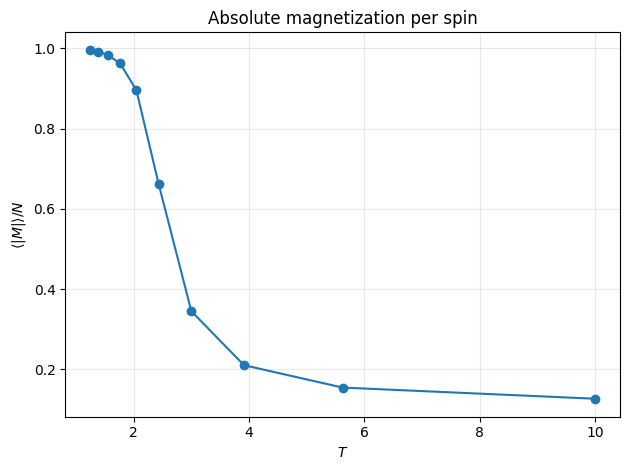

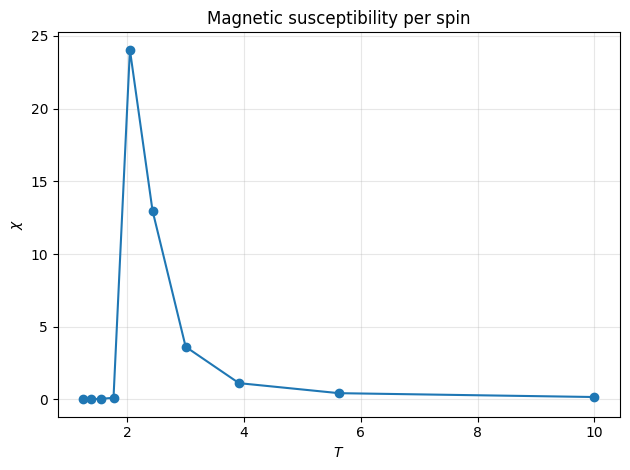

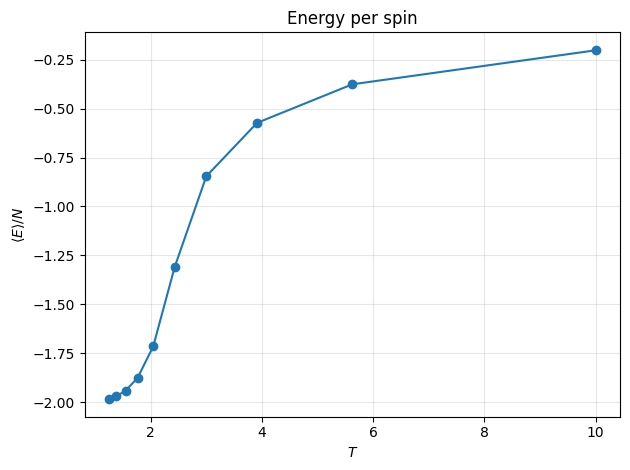

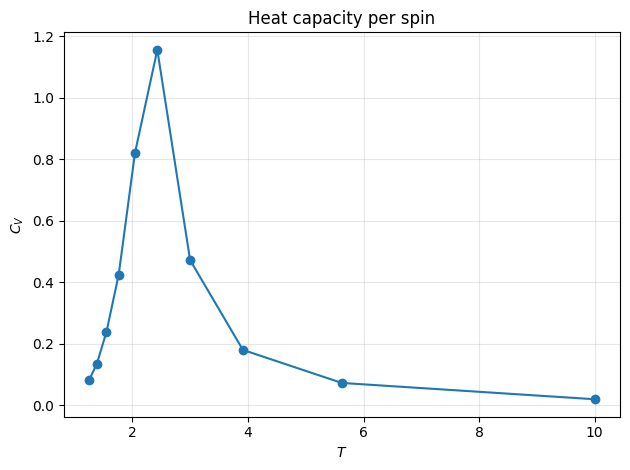

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


def nn_sum(x, i, j):
    """
    Args:
        x: Spin configuration
        i, j: Indices describing the position of one spin

    Returns:
        Sum of the spins in x which are nearest neighbors of (i, j)
    """
    L = x.shape[0]
    result = (
        x[(i + 1) % L, j]
        + x[(i - 1) % L, j]
        + x[i, (j + 1) % L]
        + x[i, (j - 1) % L]
    )
    return int(result)


def total_energy(x):
    """
    Args:
        x: Spin configuration

    Returns:
        Total energy of configuration x.
    """
    L = x.shape[0]
    energy = 0

    for i in range(L):
        for j in range(L):
            s = x[i, j]
            energy += -J * s * (x[(i + 1) % L, j] + x[i, (j + 1) % L])

    return energy


def move(x, M, E, beta_t):
    """
    Args:
        x: Spin configuration
        M: Magnetization of x
        E: Energy of x
        beta_t: inverse temperature for current run

    Returns:
        Updated x, M and E after one Monte Carlo move
    """
    # pick one random site
    i = np.random.randint(0, x.shape[0])
    j = np.random.randint(0, x.shape[1])

    s = x[i, j]
    h = nn_sum(x, i, j)

    dE = 2 * J * s * h

    # metropolis acceptance probability
    if dE <= 0:
        R = 1.0
    else:
        R = np.exp(-beta_t * dE)

    eta = np.random.rand()
    if R > eta:
        x[i, j] = -s
        M += -2 * s
        E += dE

    return x, M, E


# Parameters
L = 8                      #I only try this for L=8, later on I try all the other L's as well, for better results.
N = L**2
J = 1
beta = np.linspace(0.1, 0.8, 10)   # inverse temperatures (I plot for T not for beta) 
T = 1.0 / beta

Nthermalization_sweeps = 2000
Nsample = 5000
Nsubsweep = 10 * N         # decorrelation between measurements

M_arr = np.zeros_like(beta, dtype=float)
E_arr = np.zeros_like(beta, dtype=float)
M_err = np.zeros_like(beta, dtype=float)
E_err = np.zeros_like(beta, dtype=float)
chi_arr = np.zeros_like(beta, dtype=float)
cv_arr = np.zeros_like(beta, dtype=float)

for t in range(beta.size):
    beta_t = beta[t]
    print(f"Running for inverse temperature beta = {beta_t:.4f}")

    # spins -1 or +1
    x = np.random.choice([-1, 1], size=(L, L))
    M = np.sum(x)
    E = total_energy(x)

    # thermalization
    print("Thermalizing ...")
    for _ in tqdm(range(Nthermalization_sweeps * N)):
        x, M, E = move(x, M, E, beta_t)

    # sampling
    print("Sampling M and E ...")
    M_data = np.zeros(Nsample)
    E_data = np.zeros(Nsample)

    M_data[0] = np.abs(M) / N
    E_data[0] = E / N

    M_signed_data = np.zeros(Nsample)
    E_total_data = np.zeros(Nsample)

    M_signed_data[0] = M
    E_total_data[0] = E

    for n in tqdm(range(1, Nsample)):
        for _ in range(Nsubsweep):
            x, M, E = move(x, M, E, beta_t)

        M_data[n] = np.abs(M) / N
        E_data[n] = E / N
        M_signed_data[n] = M
        E_total_data[n] = E

    # averages
    M_arr[t] = np.mean(M_data)
    E_arr[t] = np.mean(E_data)

    # standard errors of the mean
    M_err[t] = np.std(M_data, ddof=1) / np.sqrt(Nsample)
    E_err[t] = np.std(E_data, ddof=1) / np.sqrt(Nsample)

    # fluctuation-dissipation relations
    # susceptibility per spin:
    # chi = beta/N * ( <M^2> - <M>^2 )
    chi_arr[t] = beta_t / N * (
        np.mean(M_signed_data**2) - np.mean(M_signed_data)**2
    )

    # heat capacity per spin:
    # Cv = beta^2/N * ( <E^2> - <E>^2 )
    cv_arr[t] = (beta_t**2) / N * (
        np.mean(E_total_data**2) - np.mean(E_total_data)**2
    )

# Plots 

plt.figure()
plt.errorbar(T, M_arr, yerr=M_err, fmt='o-', capsize=3)
plt.xlabel(r'$T$')
plt.ylabel(r'$\langle |M| \rangle / N$')
plt.title('Absolute magnetization per spin')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('M_vs_T.pdf')

plt.figure()
plt.plot(T, chi_arr, 'o-')
plt.xlabel(r'$T$')
plt.ylabel(r'$\chi$')
plt.title('Magnetic susceptibility per spin')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chi_vs_T.pdf')

plt.figure()
plt.errorbar(T, E_arr, yerr=E_err, fmt='o-', capsize=3)
plt.xlabel(r'$T$')
plt.ylabel(r'$\langle E \rangle / N$')
plt.title('Energy per spin')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E_vs_T.pdf')

plt.figure()
plt.plot(T, cv_arr, 'o-')
plt.xlabel(r'$T$')
plt.ylabel(r'$C_V$')
plt.title('Heat capacity per spin')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Cv_vs_T.pdf')

plt.show()


## Task 2: Determination of the Critical Temperature


In [38]:
# estimate Tc from peaks
Tc_chi = T[np.argmax(chi_arr)]
Tc_cv = T[np.argmax(cv_arr)]

print(f"Estimated Tc from susceptibility peak: {Tc_chi:.4f}")
print(f"Estimated Tc from heat capacity peak: {Tc_cv:.4f}")
print("Exact infinite-lattice value for J=1, k_B=1: Tc ≈ 2.269")

Estimated Tc from susceptibility peak: 2.0455
Estimated Tc from heat capacity peak: 2.4324
Exact infinite-lattice value for J=1, k_B=1: Tc ≈ 2.269



## Task 3: Dependence on the System Size


L=32: 100%|█████████████████████████████████████| 40/40 [15:47<00:00, 23.69s/it]


Pseudo-critical temperatures:
L= 4: Tc from chi = 1.5000, Tc from Cv = 2.3205
L= 8: Tc from chi = 2.0641, Tc from Cv = 2.3718
L=16: Tc from chi = 2.1667, Tc from Cv = 2.2692
L=32: Tc from chi = 2.3205, Tc from Cv = 2.2179

Exact thermodynamic-limit value: Tc ≈ 2.269


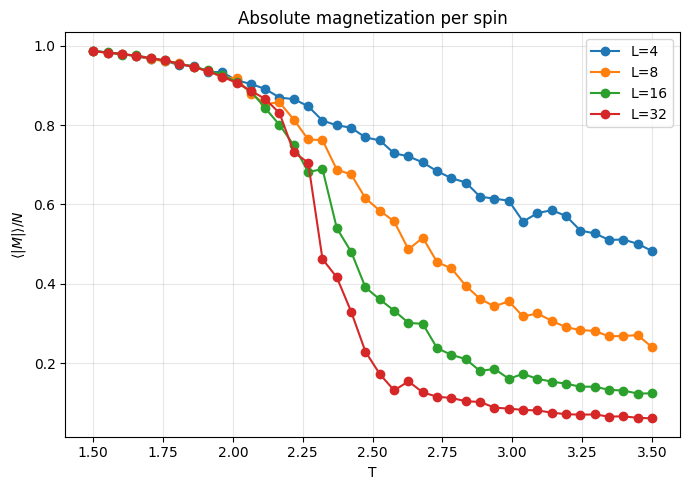

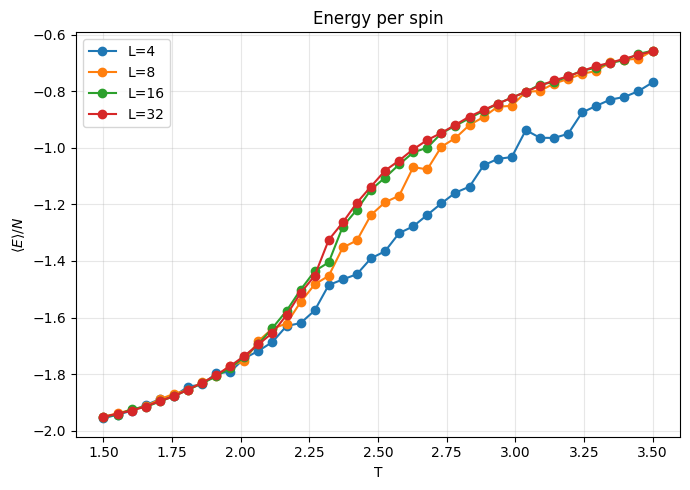

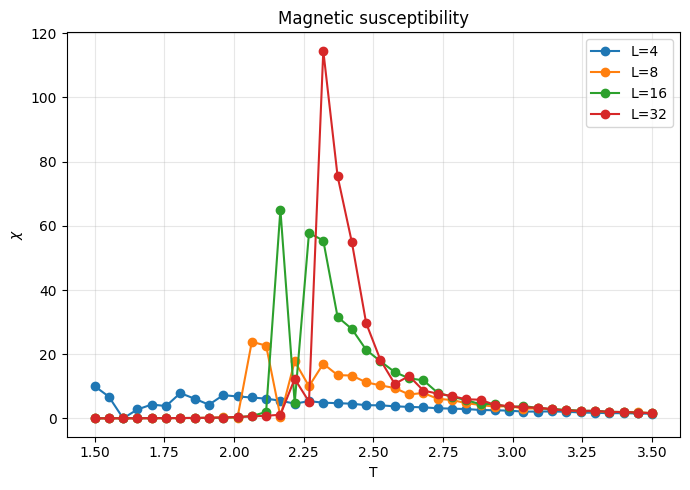

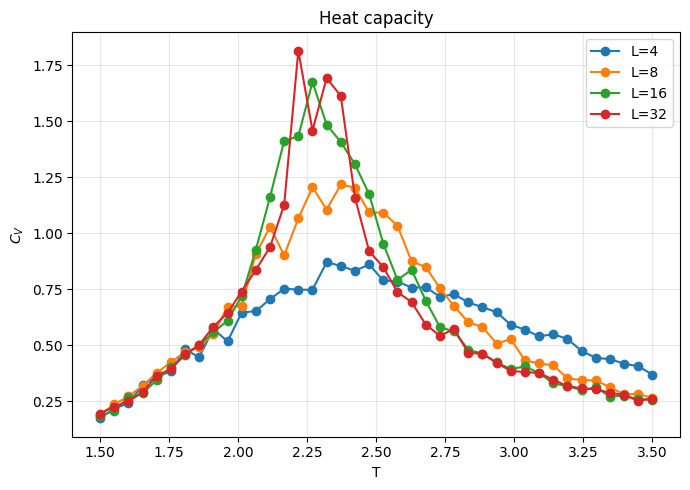

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


J = 1.0
kB = 1.0


def nn_sum(x, i, j):
    L = x.shape[0]
    return (
        x[(i + 1) % L, j]
        + x[(i - 1) % L, j]
        + x[i, (j + 1) % L]
        + x[i, (j - 1) % L]
    )


def total_energy(x):
    L = x.shape[0]
    E = 0
    for i in range(L):
        for j in range(L):
            s = x[i, j]
            E += -J * s * (x[(i + 1) % L, j] + x[i, (j + 1) % L])
    return E


def move(x, M, E, beta):
    L = x.shape[0]
    i = np.random.randint(0, L)
    j = np.random.randint(0, L)

    s = x[i, j]
    h = nn_sum(x, i, j)
    dE = 2 * J * s * h

    if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
        x[i, j] = -s
        M += -2 * s
        E += dE

    return x, M, E


def simulate_one_size(L, T_values, n_therm_sweeps=2000, n_meas=3000, sweeps_between_meas=2):
    N = L * L

    E_mean = np.zeros(len(T_values))
    Mabs_mean = np.zeros(len(T_values))
    chi = np.zeros(len(T_values))
    Cv = np.zeros(len(T_values))

    # start from random configuration
    x = np.random.choice([-1, 1], size=(L, L))
    M = np.sum(x)
    E = total_energy(x)

    for t_idx, T in enumerate(tqdm(T_values, desc=f"L={L}")):
        beta = 1.0 / (kB * T)

        # thermalization at new temp
        for _ in range(n_therm_sweeps * N):
            x, M, E = move(x, M, E, beta)

        M_signed_samples = np.zeros(n_meas)
        M_abs_samples = np.zeros(n_meas)
        E_samples = np.zeros(n_meas)

        for n in range(n_meas):
            for _ in range(sweeps_between_meas * N):
                x, M, E = move(x, M, E, beta)

            M_signed_samples[n] = M
            M_abs_samples[n] = abs(M)
            E_samples[n] = E

        E_mean[t_idx] = np.mean(E_samples) / N
        Mabs_mean[t_idx] = np.mean(M_abs_samples) / N

        chi[t_idx] = beta / N * (
            np.mean(M_signed_samples**2) - np.mean(M_signed_samples)**2
        )

        Cv[t_idx] = beta**2 / N * (
            np.mean(E_samples**2) - np.mean(E_samples)**2
        )

    return E_mean, Mabs_mean, chi, Cv


# temp around the critical
T_values = np.linspace(1.5, 3.5, 40)

# diff system sizes
L_values = [4, 8, 16, 32]

results = {}

for L in L_values:
    results[L] = simulate_one_size(
        L,
        T_values,
        n_therm_sweeps=1500,
        n_meas=2000,
        sweeps_between_meas=2
    )

# Estimate critical temp
print("\nPseudo-critical temperatures:")
for L in L_values:
    E_mean, Mabs_mean, chi, Cv = results[L]
    Tc_chi = T_values[np.argmax(chi)]
    Tc_Cv = T_values[np.argmax(Cv)]
    print(f"L={L:2d}: Tc from chi = {Tc_chi:.4f}, Tc from Cv = {Tc_Cv:.4f}")

print("\nExact thermodynamic-limit value: Tc ≈ 2.269")

# Plots
plt.figure(figsize=(7, 5))
for L in L_values:
    E_mean, Mabs_mean, chi, Cv = results[L]
    plt.plot(T_values, Mabs_mean, 'o-', label=f'L={L}')
plt.xlabel('T')
plt.ylabel(r'$\langle |M| \rangle / N$')
plt.title('Absolute magnetization per spin')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 5))
for L in L_values:
    E_mean, Mabs_mean, chi, Cv = results[L]
    plt.plot(T_values, E_mean, 'o-', label=f'L={L}')
plt.xlabel('T')
plt.ylabel(r'$\langle E \rangle / N$')
plt.title('Energy per spin')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 5))
for L in L_values:
    E_mean, Mabs_mean, chi, Cv = results[L]
    plt.plot(T_values, chi, 'o-', label=f'L={L}')
plt.xlabel('T')
plt.ylabel(r'$\chi$')
plt.title('Magnetic susceptibility')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(7, 5))
for L in L_values:
    E_mean, Mabs_mean, chi, Cv = results[L]
    plt.plot(T_values, Cv, 'o-', label=f'L={L}')
plt.xlabel('T')
plt.ylabel(r'$C_V$')
plt.title('Heat capacity')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


## Task 4: Optimization Using a Probability Lookup Table


L=32: 100%|█████████████████████████████████████| 40/40 [15:01<00:00, 22.53s/it]



Estimated pseudo-critical temperatures:
L =  4 | Tc from chi peak = 1.5513 | Tc from Cv peak = 2.4231
L =  8 | Tc from chi peak = 2.2179 | Tc from Cv peak = 2.4231
L = 16 | Tc from chi peak = 2.2692 | Tc from Cv peak = 2.3205
L = 32 | Tc from chi peak = 2.3205 | Tc from Cv peak = 2.2692

Exact Tc for 2D Ising (J=1, kB=1): 2.269185


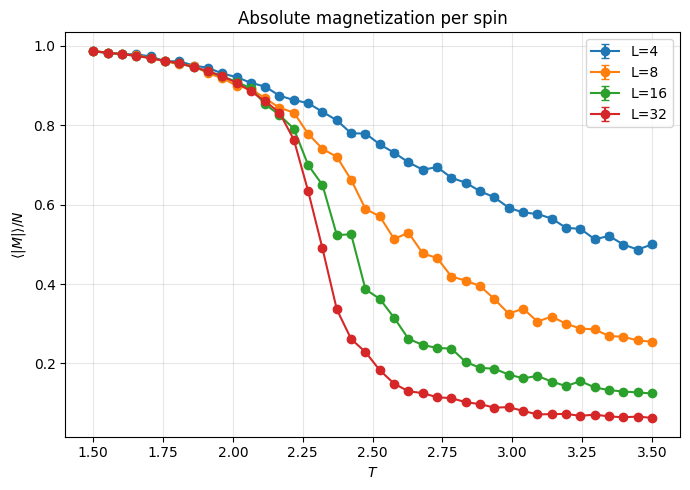

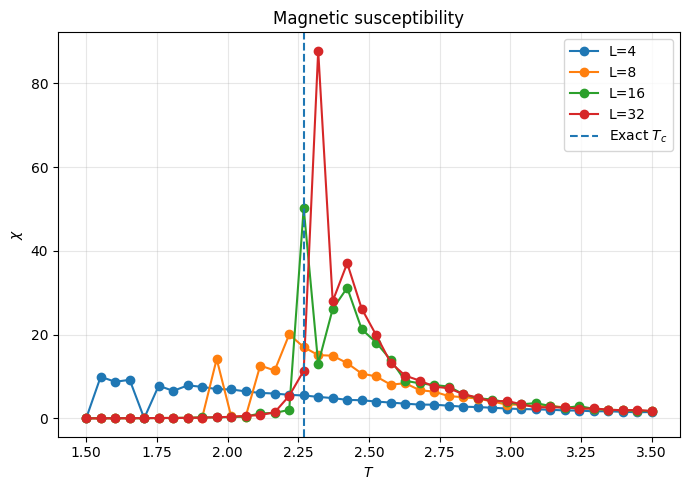

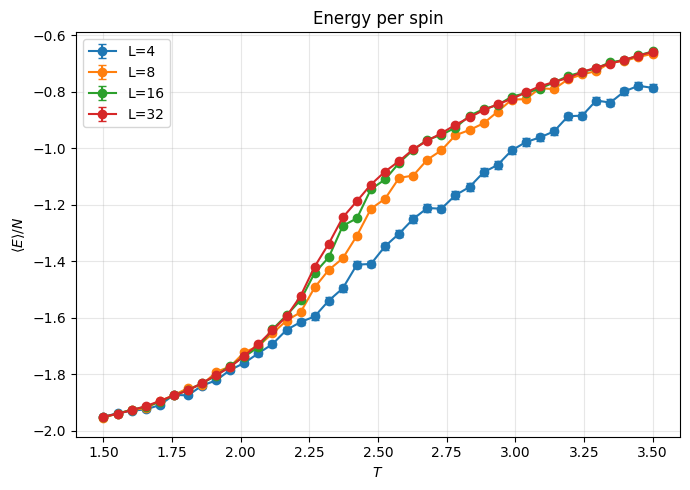

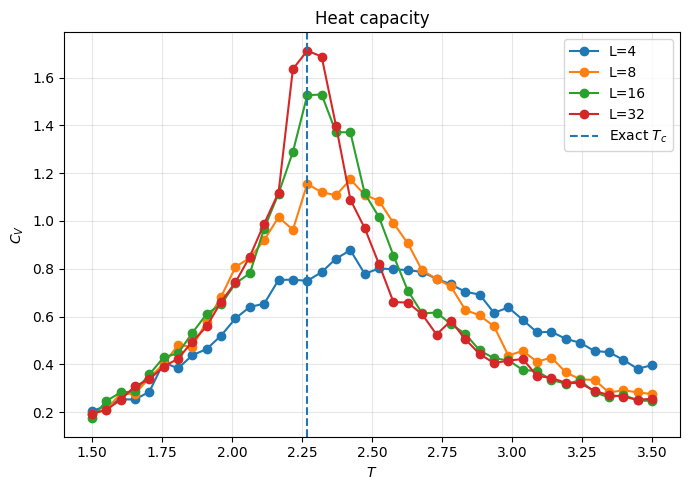

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


J = 1.0
kB = 1.0


def nn_sum(x, i, j):
    """
    Args:
        x: Spin configuration
        i, j: Indices describing the position of one spin

    Returns:
        Sum of the spins in x which are nearest neighbors of (i, j)
    """
    L = x.shape[0]
    result = (
        x[(i + 1) % L, j]
        + x[(i - 1) % L, j]
        + x[i, (j + 1) % L]
        + x[i, (j - 1) % L]
    )
    return int(result)


def total_energy(x):
    """
    Args:
        x: Spin configuration

    Returns:
        Total energy of configuration x.
    """
    L = x.shape[0]
    energy = 0

    for i in range(L):
        for j in range(L):
            s = x[i, j]
            energy += -J * s * (x[(i + 1) % L, j] + x[i, (j + 1) % L])

    return energy


def build_lookup(beta_t):
    """
    Optional optimization:
    possible dE values in 2D Ising are {-8J, -4J, 0, 4J, 8J}
    For J=1 these are {-8, -4, 0, 4, 8}
    """
    return {
        -8: 1.0,  # always accepted
        -4: 1.0,  # always accepted
         0: 1.0,
         4: np.exp(-beta_t * 4),
         8: np.exp(-beta_t * 8),
    }


def move(x, M, E, beta_t, w):
    """
    Args:
        x: Spin configuration
        M: Magnetization of x
        E: Energy of x
        beta_t: inverse temperature
        w: probability look-up table

    Returns:
        Updated x, M and E after one Monte Carlo move
    """
    L = x.shape[0]

    # pick one site at random
    i = np.random.randint(0, L)
    j = np.random.randint(0, L)

    s = x[i, j]

    # local field due to nearest neighbours
    h = nn_sum(x, i, j)

    # energy difference if we flip this spin
    dE = int(2 * J * s * h)

    # Metropolis acceptance probability
    R = w[dE]

    eta = np.random.rand()
    if R > eta:
        x[i, j] = -s
        M += -2 * s
        E += dE

    return x, M, E


def run_for_one_size(
    L,
    T_values,
    Nthermalization_sweeps=2000,
    Nsample=3000,
    Nsubsweep_sweeps=2,
    seed=None
):
    """
    Runs the simulation for one lattice size L and for all temperatures in T_values.

    Returns:
        dictionary with observables
    """
    if seed is not None:
        np.random.seed(seed)

    N = L**2
    beta_values = 1.0 / (kB * T_values)

    M_arr = np.zeros_like(T_values, dtype=float)
    E_arr = np.zeros_like(T_values, dtype=float)
    M_err = np.zeros_like(T_values, dtype=float)
    E_err = np.zeros_like(T_values, dtype=float)
    chi_arr = np.zeros_like(T_values, dtype=float)
    cv_arr = np.zeros_like(T_values, dtype=float)

    # random state at first
    x = np.random.choice([-1, 1], size=(L, L))
    M = np.sum(x)
    E = total_energy(x)

    for t in tqdm(range(len(T_values)), desc=f"L={L}"):
        beta_t = beta_values[t]
        w = build_lookup(beta_t)

        # thermalization
        for _ in range(Nthermalization_sweeps * N):
            x, M, E = move(x, M, E, beta_t, w)

        # measurement
        M_abs_data = np.zeros(Nsample)
        M_signed_data = np.zeros(Nsample)
        E_data = np.zeros(Nsample)

        for n in range(Nsample):
            for _ in range(Nsubsweep_sweeps * N):
                x, M, E = move(x, M, E, beta_t, w)

            M_abs_data[n] = np.abs(M) / N
            M_signed_data[n] = M
            E_data[n] = E / N

        # averages
        M_arr[t] = np.mean(M_abs_data)
        E_arr[t] = np.mean(E_data)

        # standard error of the mean
        M_err[t] = np.std(M_abs_data, ddof=1) / np.sqrt(Nsample)
        E_err[t] = np.std(E_data, ddof=1) / np.sqrt(Nsample)

        # fluctuation dissipation relations
        # susceptibility per spin
        chi_arr[t] = beta_t * N * (
            np.mean((M_signed_data / N) ** 2) - np.mean(M_signed_data / N) ** 2
        )

        # heat capacity per spin
        cv_arr[t] = (beta_t ** 2) * N * (
            np.mean(E_data ** 2) - np.mean(E_data) ** 2
        )

    # This for task 2: estimate critical temp.
    Tc_chi = T_values[np.argmax(chi_arr)]
    Tc_cv = T_values[np.argmax(cv_arr)]

    return {
        "L": L,
        "T": T_values,
        "beta": beta_values,
        "M_arr": M_arr,
        "E_arr": E_arr,
        "M_err": M_err,
        "E_err": E_err,
        "chi_arr": chi_arr,
        "cv_arr": cv_arr,
        "Tc_chi": Tc_chi,
        "Tc_cv": Tc_cv,
    }




# Main part


# Task 3: system-size dependence
L_values = [4, 8, 16, 32]


T_values = np.linspace(1.5, 3.5, 40)

results = {}

for L in L_values:
    results[L] = run_for_one_size(
        L=L,
        T_values=T_values,
        Nthermalization_sweeps=1500,
        Nsample=2000,
        Nsubsweep_sweeps=2,
        seed=1234
    )

# Print Tc estimates

print("\nEstimated pseudo-critical temperatures:")
for L in L_values:
    print(
        f"L = {L:2d} | "
        f"Tc from chi peak = {results[L]['Tc_chi']:.4f} | "
        f"Tc from Cv peak = {results[L]['Tc_cv']:.4f}"
    )

Tc_exact = 2.0 / np.log(1.0 + np.sqrt(2.0))
print(f"\nExact Tc for 2D Ising (J=1, kB=1): {Tc_exact:.6f}")


# Plots for all L


# Magnetization
plt.figure(figsize=(7, 5))
for L in L_values:
    plt.errorbar(
        results[L]["T"],
        results[L]["M_arr"],
        yerr=results[L]["M_err"],
        fmt='o-',
        capsize=3,
        label=f"L={L}"
    )
plt.xlabel(r"$T$")
plt.ylabel(r"$\langle |M| \rangle / N$")
plt.title("Absolute magnetization per spin")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("M_vs_T_allL.pdf")

# Susceptibility
plt.figure(figsize=(7, 5))
for L in L_values:
    plt.plot(
        results[L]["T"],
        results[L]["chi_arr"],
        'o-',
        label=f"L={L}"
    )
plt.axvline(Tc_exact, linestyle='--', label=r"Exact $T_c$")
plt.xlabel(r"$T$")
plt.ylabel(r"$\chi$")
plt.title("Magnetic susceptibility")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("chi_vs_T_allL.pdf")

# Energy
plt.figure(figsize=(7, 5))
for L in L_values:
    plt.errorbar(
        results[L]["T"],
        results[L]["E_arr"],
        yerr=results[L]["E_err"],
        fmt='o-',
        capsize=3,
        label=f"L={L}"
    )
plt.xlabel(r"$T$")
plt.ylabel(r"$\langle E \rangle / N$")
plt.title("Energy per spin")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("E_vs_T_allL.pdf")

# Heat capacity
plt.figure(figsize=(7, 5))
for L in L_values:
    plt.plot(
        results[L]["T"],
        results[L]["cv_arr"],
        'o-',
        label=f"L={L}"
    )
plt.axvline(Tc_exact, linestyle='--', label=r"Exact $T_c$")
plt.xlabel(r"$T$")
plt.ylabel(r"$C_V$")
plt.title("Heat capacity")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("Cv_vs_T_allL.pdf")

plt.show()






## Task 5: Magnetization as a Function of Simulation Time

Equilibrating...


100%|█████████████████████████████████████| 2000/2000 [00:00<00:00, 7108.59it/s]


Recording magnetization vs time...


100%|██████████████████████████████████| 10000/10000 [00:00<00:00, 13451.95it/s]


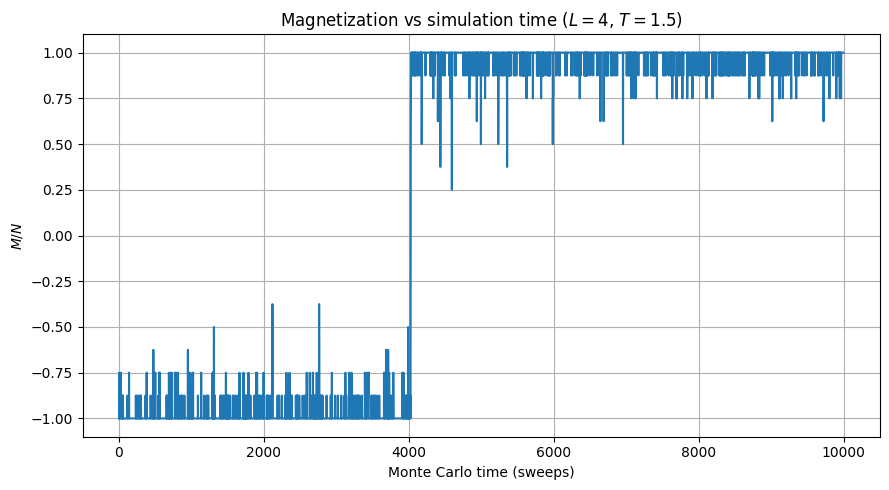

In [50]:

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm



J = 1.0
kB = 1.0

L = 4              # small lattice (to observe sign flips)
N = L * L

T = 1.5         # temperature below Tc = 2.269
beta = 1.0 / (kB * T)

N_equil_sweeps = 2000
N_meas_sweeps = 10000


def nn_sum(x, i, j):
    L = x.shape[0]
    return (
        x[(i + 1) % L, j]
        + x[(i - 1) % L, j]
        + x[i, (j + 1) % L]
        + x[i, (j - 1) % L]
    )

def total_energy(x):
    L = x.shape[0]
    E = 0.0
    for i in range(L):
        for j in range(L):
            s = x[i, j]
            E += -J * s * x[(i + 1) % L, j]
            E += -J * s * x[i, (j + 1) % L]
    return E

# Precompute Metropolis probabilities (Task 4 optimisation)
def build_prob_table(beta):
    return {
        -8: 1.0,
        -4: 1.0,
         0: 1.0,
         4: np.exp(-beta * 4.0),
         8: np.exp(-beta * 8.0),
    }

def metropolis_move(x, M, E, prob_table):
    L = x.shape[0]

    i = np.random.randint(0, L)
    j = np.random.randint(0, L)

    s = x[i, j]
    h = nn_sum(x, i, j)

    dE = int(2 * J * s * h)

    if np.random.rand() < prob_table[dE]:
        x[i, j] = -s
        M -= 2 * s
        E += dE

    return x, M, E

# One Monte Carlo sweep = N spin updates
def sweep(x, M, E, prob_table):
    for _ in range(N):
        x, M, E = metropolis_move(x, M, E, prob_table)
    return x, M, E

# Initialization

prob_table = build_prob_table(beta)

x = np.random.choice([-1, 1], size=(L, L))
M = np.sum(x)
E = total_energy(x)

# Equilibration

print("Equilibrating...")
for _ in tqdm(range(N_equil_sweeps)):
    x, M, E = sweep(x, M, E, prob_table)

# Measurement of M(t)

print("Recording magnetization vs time...")
M_time = np.zeros(N_meas_sweeps)

for t in tqdm(range(N_meas_sweeps)):
    x, M, E = sweep(x, M, E, prob_table)
    M_time[t] = M / N   # magnetization per spin


# plot
time = np.arange(N_meas_sweeps)

plt.figure(figsize=(9,5))
plt.plot(time, M_time)
plt.xlabel("Monte Carlo time (sweeps)")
plt.ylabel(r"$M/N$")
plt.title(fr"Magnetization vs simulation time ($L={L}$, $T={T}$)")
plt.grid(True)

plt.tight_layout()
plt.savefig("task5_M_vs_time.pdf")
plt.show()


## Error Estimation Using Binning

Running for inverse temperature = 0.1
Thermalizing ...


100%|███████████████████████████████| 100000/100000 [00:00<00:00, 130277.59it/s]


Sampling M and E ...


100%|██████████████████████████████████████| 4999/4999 [00:11<00:00, 424.83it/s]


Running for inverse temperature = 0.17777777777777778
Thermalizing ...


...

100%|██████████████████████████████████████| 4999/4999 [00:10<00:00, 465.98it/s]


Running for inverse temperature = 0.8
Thermalizing ...


100%|███████████████████████████████| 100000/100000 [00:00<00:00, 296762.24it/s]


Sampling M and E ...


100%|██████████████████████████████████████| 4999/4999 [00:10<00:00, 464.58it/s]


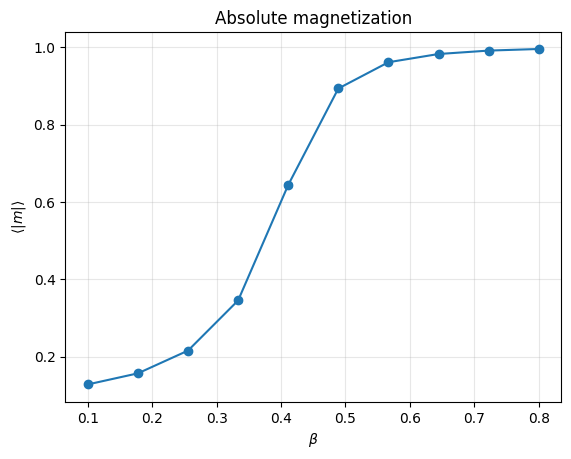

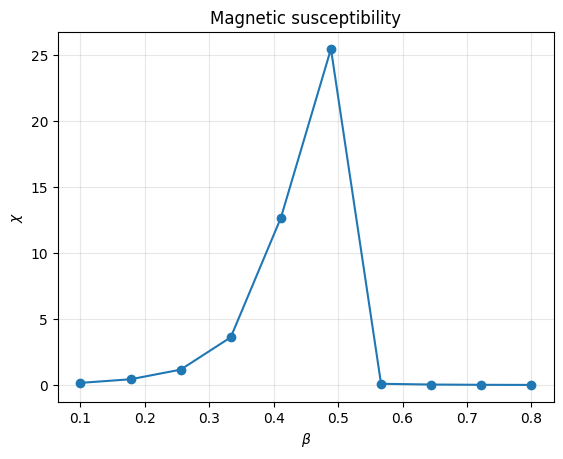

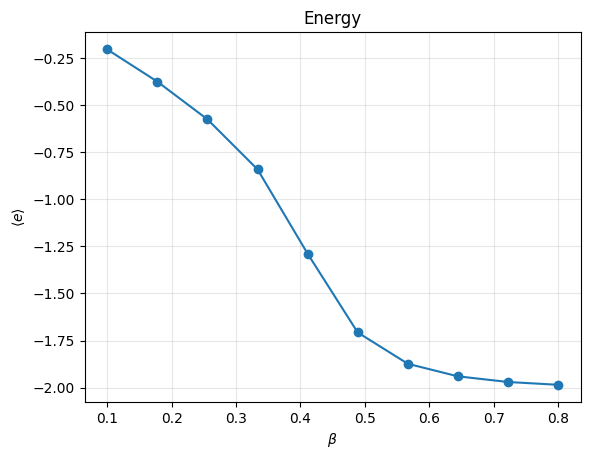

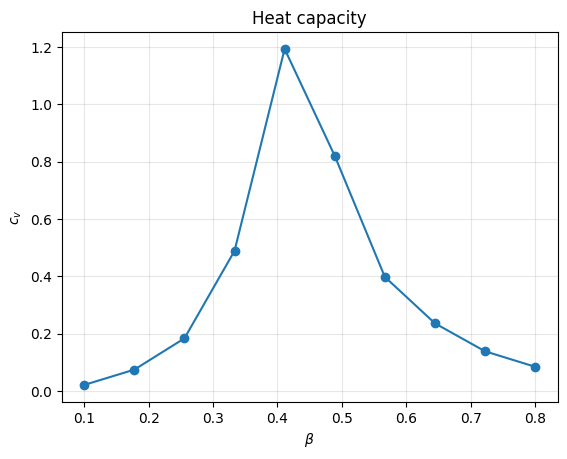

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


def nn_sum(x, i, j):
    result = (
        x[(i + 1) % L, j] +
        x[(i - 1) % L, j] +
        x[i, (j + 1) % L] +
        x[i, (j - 1) % L]
    )
    return int(result)


def total_energy(x):
    energy = 0
    for i in range(L):
        for j in range(L):
            s = x[i, j]
            
            energy += -J * s * x[(i + 1) % L, j]
            energy += -J * s * x[i, (j + 1) % L]
    return energy


def move(x, M, E, beta_t):
    i = np.random.randint(0, L)
    j = np.random.randint(0, L)

    s = x[i, j]
    h = nn_sum(x, i, j)
    dE = 2 * J * s * h

    R = min(1.0, np.exp(-beta_t * dE))

    if R > np.random.rand():
        x[i, j] = -s
        M -= 2 * s
        E += dE

    return x, M, E


def blocking_error(data, block_size):
    """
    Estimate the standard error of the mean using blocking analysis.

    Args:
        data: 1D array of Monte Carlo measurements
        block_size: number of consecutive samples per block

    Returns:
        error estimate from block averages
    """
    n = len(data)
    n_blocks = n // block_size

    if n_blocks < 2:
        raise ValueError("block_size too large: need at least 2 blocks")

    trimmed = data[:n_blocks * block_size]
    blocks = trimmed.reshape(n_blocks, block_size)
    block_means = np.mean(blocks, axis=1)

    return np.std(block_means, ddof=1) / np.sqrt(n_blocks)


# parameters
L = 8
N = L**2
J = 1
beta = np.linspace(0.1, 0.8, 10)

Nthermalization = int(1e5)
Nsample = 5000
Nsubsweep = 10 * N

# binning choice
block_size = 20   # can try 10, 20, 50, 100 and check stability

M_arr = np.zeros_like(beta)
E_arr = np.zeros_like(beta)
M_err = np.zeros_like(beta)
E_err = np.zeros_like(beta)
chi_arr = np.zeros_like(beta)
cv_arr = np.zeros_like(beta)

for t in range(beta.size):
    beta_t = beta[t]
    print('Running for inverse temperature =', beta_t)

    x = np.random.choice([-1, 1], size=(L, L))
    M = np.sum(x)
    E = total_energy(x)

    print('Thermalizing ...')
    for _ in tqdm(range(Nthermalization)):
        x, M, E = move(x, M, E, beta_t)

    print('Sampling M and E ...')
    M_data = np.zeros(Nsample)
    E_data = np.zeros(Nsample)
    M_signed_data = np.zeros(Nsample)

    M_data[0] = np.abs(M) / N
    M_signed_data[0] = M / N
    E_data[0] = E / N

    for n in tqdm(range(1, Nsample)):
        for _ in range(Nsubsweep):
            x, M, E = move(x, M, E, beta_t)

        M_data[n] = np.abs(M) / N
        M_signed_data[n] = M / N
        E_data[n] = E / N

    M_arr[t] = np.mean(M_data)
    E_arr[t] = np.mean(E_data)

    # error bars
    M_err[t] = blocking_error(M_data, block_size)
    E_err[t] = blocking_error(E_data, block_size)

    chi_arr[t] = beta_t * N * (np.mean(M_signed_data**2) - np.mean(M_signed_data)**2)
    cv_arr[t] = beta_t**2 * N * (np.mean(E_data**2) - np.mean(E_data)**2)


# plots
plt.figure()
plt.errorbar(beta, M_arr, yerr=M_err, fmt='o-', capsize=3)
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\langle |m| \rangle$')
plt.title('Absolute magnetization')
plt.grid(alpha=0.3)
plt.savefig('M.pdf')

plt.figure()
plt.plot(beta, chi_arr, 'o-')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\chi$')
plt.title('Magnetic susceptibility')
plt.grid(alpha=0.3)
plt.savefig('chi.pdf')

plt.figure()
plt.errorbar(beta, E_arr, yerr=E_err, fmt='o-', capsize=3)
plt.xlabel(r'$\beta$')
plt.ylabel(r'$\langle e \rangle$')
plt.title('Energy')
plt.grid(alpha=0.3)
plt.savefig('E.pdf')

plt.figure()
plt.plot(beta, cv_arr, 'o-')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$c_v$')
plt.title('Heat capacity')
plt.grid(alpha=0.3)
plt.savefig('cv.pdf')

plt.show()

In [52]:
print("beta values:")
print(beta)

print("\nMagnetization error bars (M_err):")
print(M_err)

print("\nEnergy error bars (E_err):")
print(E_err)

beta values:
[0.1        0.17777778 0.25555556 0.33333333 0.41111111 0.48888889
 0.56666667 0.64444444 0.72222222 0.8       ]

Magnetization error bars (M_err):
[0.0013052  0.00169013 0.00200597 0.00355487 0.004907   0.00195396
 0.00075345 0.00045972 0.00027616 0.00017376]

Energy error bars (E_err):
[0.00265477 0.00262852 0.0030085  0.00393354 0.00582194 0.00357981
 0.00205669 0.00148951 0.0009618  0.00063679]


In [53]:
T = 1 / beta

for i in range(len(beta)):
    print(f"T = {T[i]:.3f}, beta = {beta[i]:.3f}, M_err = {M_err[i]:.6f}, E_err = {E_err[i]:.6f}")

T = 10.000, beta = 0.100, M_err = 0.001305, E_err = 0.002655
T = 5.625, beta = 0.178, M_err = 0.001690, E_err = 0.002629
T = 3.913, beta = 0.256, M_err = 0.002006, E_err = 0.003008
T = 3.000, beta = 0.333, M_err = 0.003555, E_err = 0.003934
T = 2.432, beta = 0.411, M_err = 0.004907, E_err = 0.005822
T = 2.045, beta = 0.489, M_err = 0.001954, E_err = 0.003580
T = 1.765, beta = 0.567, M_err = 0.000753, E_err = 0.002057
T = 1.552, beta = 0.644, M_err = 0.000460, E_err = 0.001490
T = 1.385, beta = 0.722, M_err = 0.000276, E_err = 0.000962
T = 1.250, beta = 0.800, M_err = 0.000174, E_err = 0.000637


In [54]:
import pandas as pd

T = 1 / beta

df_errors = pd.DataFrame({
    "T": T,
    "beta": beta,
    "M_mean": M_arr,
    "M_err": M_err,
    "E_mean": E_arr,
    "E_err": E_err,
    "chi": chi_arr,
    "cv": cv_arr
})

df_errors

,T,beta,M_mean,M_err,E_mean,E_err,chi,cv
0,10.000000,0.100000,0.127887,0.001305,-0.205025,0.002655,0.162795,0.020990
1,5.625000,0.177778,0.156575,0.001690,-0.375800,0.002629,0.436102,0.074318
2,3.913043,0.255556,0.215438,0.002006,-0.576025,0.003008,1.164499,0.183347
3,3.000000,0.333333,0.345244,0.003555,-0.841275,0.003934,3.614880,0.488512
4,2.432432,0.411111,0.644169,0.004907,-1.288900,0.005822,12.654934,1.192712
5,2.045455,0.488889,0.893756,0.001954,-1.707013,0.003580,25.447877,0.819976
6,1.764706,0.566667,0.961738,0.000753,-1.873250,0.002057,0.094422,0.397730
7,1.551724,0.644444,0.983019,0.000460,-1.939900,0.001490,0.036754,0.235742
8,1.384615,0.722222,0.991869,0.000276,-1.969925,0.000962,0.016308,0.138284
9,1.250000,0.800000,0.996012,0.000174,-1.984825,0.000637,0.007886,0.084328
